In [65]:
# Pip installs
!pip3 install matplotlib
!pip3 install scipy
!pip3 install matplotlib_venn
!pip3 install seaborn
!pip3 install nltk
!pip3 install sklearn

# NLP imports
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import numpy as np

# imports
import json
from datetime import datetime
import dateutil.parser as parser
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import math
from scipy import stats

# nltk downloads
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')
nltk.download('wordnet')

# load articles function
def load_articles(loc):
  with open(loc, encoding='utf-8') as f:
    articles_raw = json.load(f)

  articles = []
  for a in articles_raw:
      # ignore 2025 articles
      if a['published'] < 1735689600:
        articles.append(a)

  return pd.DataFrame.from_records(articles)

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Figure 3

In [66]:
# This block will just display how many articles from each paper
# And combined length of all articles from each paper
df = load_articles('./final_data.json')
# Count all where paper = daily mail and guardian
df_count = df['paper'].value_counts().reset_index()
df_count.columns = ['paper', 'count']
df_count = df_count.set_index('paper')
# Load dataframe

# combined length
# append all bodies of each paper
df_count['bodies_size'] = df.groupby('paper')['body'].apply(lambda x: len(' '.join(x).split()))
# add sum row
df_count.loc['total'] = df_count.sum()

# convert total articles to str
df_count['total articles'] = df_count['count'].apply(lambda x : str(x) + " (" + str(round(100 * x / df_count.loc['total']['count'])) + "%)")
df_count['total words'] = df_count['bodies_size'].apply(lambda x : str(x) + " (" + str(round(100 * x / df_count.loc['total']['bodies_size'])) + "%)")

df_count[['total articles', 'total words']].head(5)

,total articles,total words
paper,,
guardian,252 (55%),204877 (52%)
dailymail,208 (45%),190958 (48%)
total,460 (100%),395835 (100%)


Figure 4

<Figure size 3000x300 with 0 Axes>

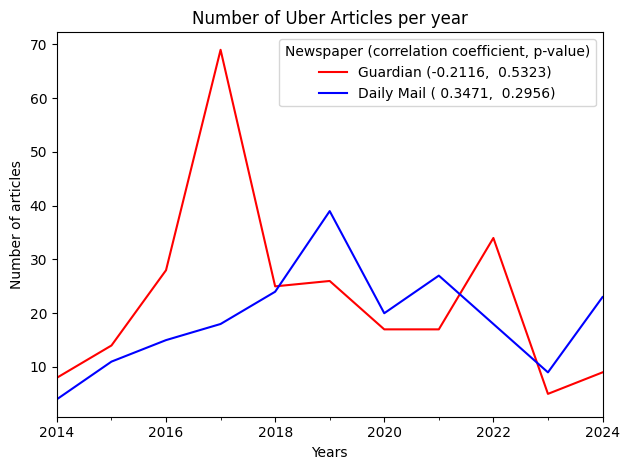

In [67]:
# This creates the plot that shows number of uber articles by month/year

# 1. get the data
obj_old = {}
obj = []
with open('./final_data.json', encoding='utf-8') as f:
    obj_old = json.load(f)

resolution = 1

def get_frequency_df(obj, resolution):

    # What I need is a df of form PAPER/MONTH(everymonth)/COUNT
    # Need to know earliest month and year and latest month and year (use published)
    # Sort obj by published - do it with data frame

    df = pd.DataFrame.from_records(obj).sort_values('published')
    # Get first timestamps
    first = (df.iloc[0]['published'])
    first = datetime.fromtimestamp(first)

    # ignore 2025
    all_years = [y for y in range(int(first.year), 2024 + 1)]
    all_months = [str(y) + "-" + ("0" if m < 10 else "") + str(m) + "-01" for m in range(1,13) for y in range(first.year, 2025 + 1)]

    # df2 is used only for the time plot

    df2dict = {
        m : {
            'guardian': 0,
            'dailymail': 0
        } for m in all_months
    }

    df2 = pd.DataFrame.from_records(df2dict).transpose()

    def month_function(m):
        return round(((m - 1)//(12/resolution)) * (12/resolution) + 1)

    # months that are possible given resolution
    possible_months = set([month_function(x) for x in range(1,13)])

    # Loop through df
    for index, row in df.iterrows():
        # Convert time to first of given month/year
        month = datetime.fromtimestamp(row['published'])
        # rounded month
        m = month_function(month.month)
        month = month.strftime('%Y-' + ("0" if m < 10 else "") + str(m) + '-01')
        paper = row['paper']
        # update df2 accordingly
        df2.loc[month, paper] += 1


    # convert index to datetime
    df2.index = pd.to_datetime(df2.index)

    # drop months that haven't happened
    # let's ignore 2025 because it hasn't been a full years
    df2= df2[(df2.index.year != 2025)]

    #this step is for accounting for month resolution
    df2 = df2[df2.index.month.isin(possible_months)]
    return df2

df2 = get_frequency_df(obj_old, 1)

plt.figure(figsize=(20, 2), dpi=150)
df2.plot(label="Paper", color=['red', 'blue'])

plt.title('Number of Uber Articles per year')
plt.xlabel('Years')
plt.ylabel("Number of articles")

# get the correlation between year published and number of articles for each paper
dm_c, dm_p = stats.pearsonr(df2.index.year, df2['dailymail'])
g_c, g_p = stats.pearsonr(df2.index.year, df2['guardian'])

plt.legend([f'Guardian ({g_c : .4f}, {g_p : .4f})', f'Daily Mail ({dm_c : .4f}, {dm_p : .4f})']).set_title('Newspaper (correlation coefficient, p-value)')
# adding legend.
plt.tight_layout()
plt.show()

Figure 5

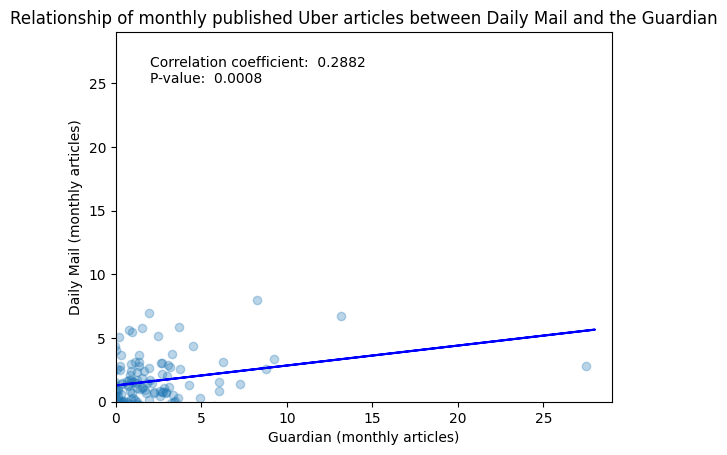

In [68]:
# this for checking if there's any correlation between how many articles daily mail publish and guardian do each month
df_corr = get_frequency_df(obj_old, 12)

# plot scatter plot of guardian and dailymail
import random

# add random jitter to make better visualisation
plt.scatter(df_corr['guardian'].apply(lambda x : x + random.random() - 0.5), df_corr['dailymail'].apply(lambda x : x + random.random() - 0.5), alpha=0.3)

gca = plt.gca()
xlim = math.ceil(gca.get_xlim()[1])
ylim = math.ceil(gca.get_ylim()[1])
bigger = xlim
if xlim > ylim: bigger = xlim
elif ylim > xlim: bigger = ylim
else: bigger = xlim
plt.xlim(0, bigger)
plt.ylim(0, bigger)

# Calculate the correlation coefficient and p-value
correlation_coefficient, p_value = stats.pearsonr(df_corr['guardian'], df_corr['dailymail'])

#plot line of best fit
m, b = np.polyfit(df_corr['guardian'], df_corr['dailymail'], 1)
plt.plot(df_corr['guardian'], m*df_corr['guardian'] + b, color='blue')


# Display the results on the graph
plt.text(2, 25, f'Correlation coefficient: {correlation_coefficient : .4f} \nP-value: {p_value : .4f}')
plt.title("Relationship of monthly published Uber articles between Daily Mail and the Guardian")
plt.xlabel("Guardian (monthly articles)")
plt.ylabel("Daily Mail (monthly articles)")

plt.show()



This block introduces some important functions (particularly collapse df) that are used by many subsequent functions and visualisations

In [69]:
# sentiment analysis of daily mail and uber
# do separately by headline and content
# First exercise - count most frequent words of each article
import json
# Let's try headline first
# First we load the data

df = load_articles('./final_data.json')

def most_frequent_words(text):
    words = word_tokenize(text.lower())
    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()
    filtered_words = [stemmer.stem(word) for word in words if word.isalnum() and word not in stop_words]
    filtered_word_counts = Counter(filtered_words)
    return filtered_word_counts.most_common()

# remove all words with compound sentiment between +/-neut (exclusive)
# sentiment dict just to save compute
sent_dict = {}
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    # add single words to sent_dict
    if " " not in text:
      if text not in sent_dict:
          sent_dict[text] = sia.polarity_scores(text)['compound']
      return sent_dict[text]
    else:
        sent_dict[text] = sia.polarity_scores(text)['compound']
        return sent_dict[text]


# Reveals the most important words in an article given
# The frequency of these words in general
def tf_idf_scores(text, neut=0):
    documents = [text]
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(documents)
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = tfidf_matrix.toarray()[0]
    tfidf_dict = dict(zip(feature_names, tfidf_scores))
    tfidf_dict = dict(sorted(tfidf_dict.items(), key=lambda item: item[1], reverse=True))
    # Remove entries that include numbers because these rarely indicate anything
    for key in list(tfidf_dict.keys()):
        if any(char.isdigit() for char in key) or get_sentiment(key) < neut and get_sentiment(key) > -neut:
            del tfidf_dict[key]
    return tfidf_dict


def collapse_df_dates(df, m_res, y_res = 1):
    # remove 2025 dates because incomplete
    df = df.copy()[df['published'] < 1735689600]
    def month_function(m):
        return round(((m - 1)//(12/m_res)) * (12/m_res) + 1)

    first_year = df['published'].min()
    first_year = datetime.fromtimestamp(first_year)
    first_year = first_year.year

    def year_function(y):
      x = y - first_year
      return (int(math.floor(x / y_res)) * y_res) + first_year

    def date_function(timestamp):
        d = datetime.fromtimestamp(timestamp)
        m = month_function(d.month)
        d = d.replace(month=m, day=1)
        if not y_res == 1: y = year_function(d.year)
        else: y = d.year
        d = d.replace(year=y)
        month = d.strftime('%Y-%m-%d')
        return month

    df['published'] = df['published'].apply(date_function)
    return df

def collapse_df(df, m_res, y_res):
    df = collapse_df_dates(df, m_res, y_res)

    df2 = pd.DataFrame.from_dict({
        "published" : df['published'].unique()
    })
    def concat_headlines(pub):
        x = "\n".join(df[df['published'] == pub]['headline'])
        return x
    def concat_bodies(pub):
        x = "\n".join(df[df['published'] == pub]['body'])
        return x

    df2['headlines'] = df2['published'].apply(concat_headlines)
    df2['bodies'] = df2['published'].apply(concat_bodies)

    # sort by date
    df2 = df2.sort_values(by=['published'])
    df2.set_index('published', inplace=True)
    """df2 = df2.transpose()
    df2 = df2.map(str)"""

    # add missing dates
    first = (df2.index[0])
    first = datetime.strptime(first, '%Y-%m-%d')
    # ignore 2025
    all_years = [y for y in range(int(first.year), 2024 + 1)]
    all_months = [str(y) + "-" + ("0" if (m * (12/m_res) + 1) < 10 else "") + str(int(m * (12/m_res) + 1)) + "-01" for m in range(0,m_res) for y in range(first.year, 2024 + 1)]

    # add month with blank headlines and bodies if not in df
    for month in all_months:
        if month not in df2.index:
          # add row to df
          df2.loc[month] = [""] * len(df2.columns)

    # do tf_idf_scores
    return df2

# could use topic modelling

def df_idf_table(df, top_n, neut = 0):
  df2 = df.copy()

  df2['headlines_tf'] = df['headlines'].apply(tf_idf_scores, neut=neut)
  df2['bodies_tf'] = df['bodies'].apply(tf_idf_scores, neut=neut)
  for i in range(0, top_n):
    df2['h' + str(i)] = df2['headlines_tf'].apply(lambda x: list(x.keys())[i] if i < len(x) else "")
    df2['b' + str(i)] = df2['bodies_tf'].apply(lambda x: list(x.keys())[i] if i < len(x) else "")
  df2.drop(columns=['headlines_tf', 'bodies_tf', 'headlines', 'bodies'], inplace=True)
  # sort by date
  df2 = df2.sort_values(by=['published'])
  print(df2.columns)
  df2.set_index('published', inplace=True)
  print("BELLO")
  df2 = df2.transpose()
  df2 = df2.map(str)
  return df2

def heatmap_df(df, m_res = 1, y_res = 1, top_n = 10, neut = 0, paper = None):
  if paper != None:
    df = df.copy()[df['paper'] == paper]
  df = collapse_df(df, m_res, y_res)
  df = df_idf_table(df, 10, neut=0.2)
  df_vals = df.copy().map(get_sentiment)
  fig, ax = plt.subplots(figsize=(20,10))
  sns.heatmap(df_vals, annot=df, fmt="", cmap="icefire_r", vmin=-1, vmax=1)
  plt.show()

def get_topics_text(text):
  vectorizer = TfidfVectorizer(stop_words='english', max_df=.95, min_df=.05)
  article_body_transformed= vectorizer.fit_transform(sent_tokenize(text))
  lda = LatentDirichletAllocation(n_components=5, random_state=42)
  lda.fit(article_body_transformed)
  feature_names = vectorizer.get_feature_names_out()
  for topic_idx, topic in enumerate(lda.components_):
      print(f"Topic {topic_idx}:")
      print(" ".join([feature_names[i] for i in topic.argsort()[:-10 - 1:-1]]))

#heatmap_df(df, 1, 1, 10, 0.2)






Figures 6 and 7

<ipython-input-50-4c0c737fbe51>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(df_slice['headline_sentiment'], pol(df_slice['headline_sentiment']), "r--", color=c)


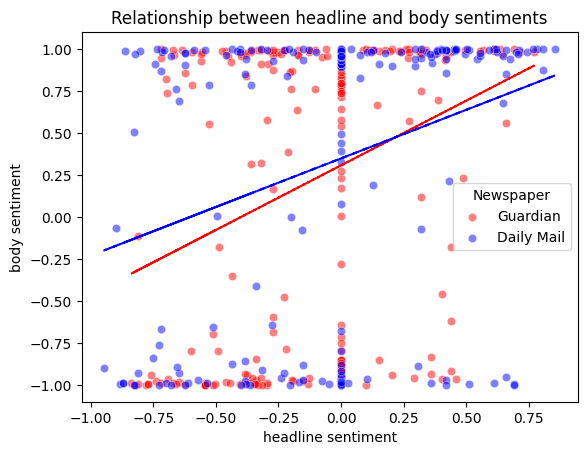

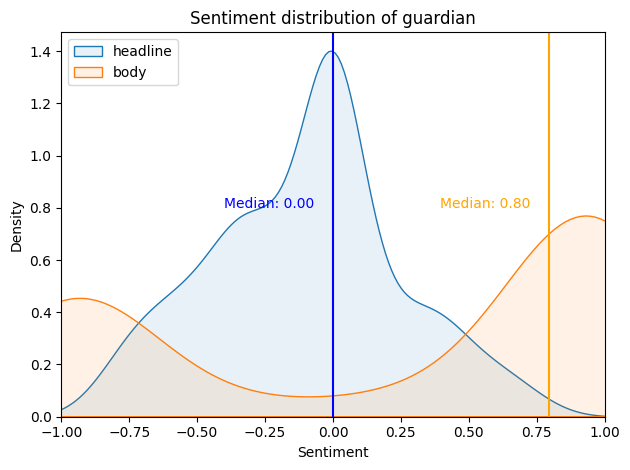

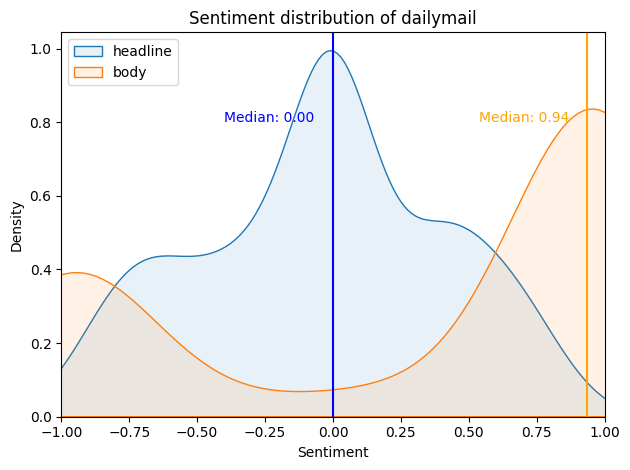

In [50]:
# This block will plot sentiment of a headline against body
df = load_articles('./final_data.json')
# preserve published, body, headline (index)
df = df[['published', 'paper', 'headline', 'body']]

# get sentiments of headline and body
df['headline_sentiment'] = df['headline'].apply(get_sentiment)
df['body_sentiment'] = df['body'].apply(get_sentiment)

# plot sentiment of headline against body for each news paper
for p, c in zip(['guardian', 'dailymail'], ['red', 'blue']):
  df_slice = df[df['paper'] == p]
  sns.scatterplot(data=df[df['paper'] == p], x="headline_sentiment", y="body_sentiment", alpha = 0.5, color=c)

# add lines of best fit
for p, c in zip(['guardian', 'dailymail'], ['red', 'blue']):
  df_slice = df[df['paper'] == p]
  z = np.polyfit(df_slice['headline_sentiment'], df_slice['body_sentiment'], 1)
  pol = np.poly1d(z)
  # print pearson test coefficient and p-value
  #print(f'Pearson test coefficient for {p}: {stats.pearsonr(df_slice["headline_sentiment"], df_slice["body_sentiment"])}')
  plt.plot(df_slice['headline_sentiment'], pol(df_slice['headline_sentiment']), "r--", color=c)

plt.title(f'Relationship between headline and body sentiments')
# set colours as red and blue
plt.legend(['Guardian', 'Daily Mail']).set_title('Newspaper')
plt.xlabel('headline sentiment')
plt.ylabel('body sentiment')


plt.show()

# do a kde of body and headline
for p in ['guardian', 'dailymail']:
  sns.kdeplot(data=df[df['paper'] == p], x="headline_sentiment", fill=True, common_norm=False, alpha = 0.1)
  sns.kdeplot(data=df[df['paper'] == p], x="body_sentiment", fill=True, common_norm=False, alpha = 0.1)
  # get median sentiments

  median_headline_sentiment = df[df['paper'] == p]['headline_sentiment'].median()
  median_body_sentiment = df[df['paper'] == p]['body_sentiment'].median()
  plt.axvline(median_headline_sentiment, color='blue', linestyle='-')
  plt.axvline(median_body_sentiment, color='orange', linestyle='-')
  plt.text(median_headline_sentiment - 0.4, 0.8, f'Median: {median_headline_sentiment:.2f}', color='blue')  # Text annotation
  plt.text(median_body_sentiment - 0.4, 0.8, f'Median: {median_body_sentiment:.2f}', color='orange')  # Text annotation

  plt.title(f'Sentiment distribution of {p}')
  plt.xlim(-1, 1)
  plt.xlabel('Sentiment')
  plt.ylabel('Density')
  # add legend for headline and body
  plt.legend(labels=['headline', 'body'])
  plt.tight_layout()
  plt.show()


Figure 8

In [51]:
# sort by body sentiment
# this shows the articles with biggest difference between headline and body sentiment
df["sent_diff"] = abs(df['headline_sentiment'] - df['body_sentiment'])
df.sort_values(by=['sent_diff'], ascending=False, inplace=True)
df.head(3)

,published,paper,headline,body,headline_sentiment,body_sentiment,sent_diff
312,1574761116,dailymail,man with criminal caution for child porn image...,a driver who received a caution for distributi...,-0.8625,0.9893,1.8518
253,1732802225,dailymail,uber launches teen accounts - but concerned us...,uber has been slammed across social media over...,-0.8047,0.9882,1.7929
367,1658027404,dailymail,warning for travellers heading overseas to soa...,"a man paid more than $1,300 for an uber from p...",-0.8225,0.9683,1.7908


Figures 9 and 10

<ipython-input-52-7972456dad93>:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[df['paper'] == 'guardian']['headline_sentiment'], df[df['paper'] == 'dailymail']['headline_sentiment']], labels=['Guardian', 'Daily Mail'])


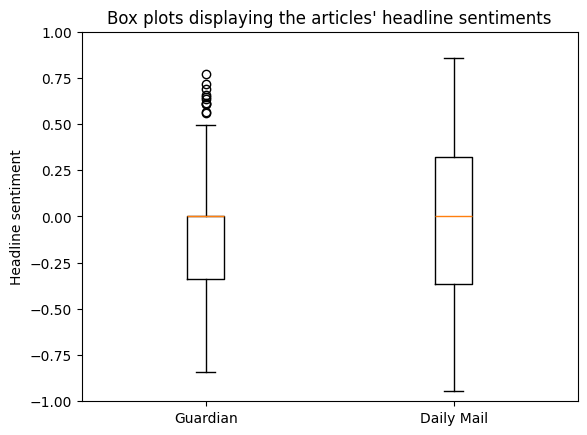

Guardian headline sentiment
count    252.000000
mean      -0.101787
std        0.347217
min       -0.840200
25%       -0.340000
50%        0.000000
75%        0.000000
max        0.771300
Name: headline_sentiment, dtype: float64
Daily Mail headline sentiment
count    208.000000
mean      -0.033834
std        0.446341
min       -0.945800
25%       -0.366900
50%        0.000000
75%        0.323650
max        0.855500
Name: headline_sentiment, dtype: float64
Daily Mail has greater headline sentiment than Guardian?
TtestResult(statistic=np.float64(-1.7930817776196772), pvalue=np.float64(0.03687129939475165), df=np.float64(386.01104650230917))


<ipython-input-52-7972456dad93>:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[df['paper'] == 'guardian']['headline_sentiment_squared'], df[df['paper'] == 'dailymail']['headline_sentiment_squared']], labels=['Guardian', 'Daily Mail'])


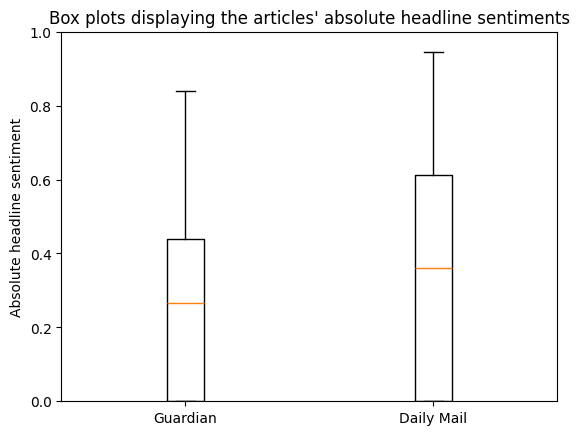

Guardian absolute headline sentiment
count    252.000000
mean       0.264948
std        0.245936
min        0.000000
25%        0.000000
50%        0.264950
75%        0.440400
max        0.840200
Name: headline_sentiment_squared, dtype: float64
Daily Mail absolute headline sentiment
count    208.000000
mean       0.342073
std        0.287735
min        0.000000
25%        0.000000
50%        0.359700
75%        0.611725
max        0.945800
Name: headline_sentiment_squared, dtype: float64
Daily Mail has greater absolute sentiment than Guardian?
TtestResult(statistic=np.float64(-3.0533002791805877), pvalue=np.float64(0.0012055910220722637), df=np.float64(409.2032689390013))


In [52]:
# i'll use headline as proxy for article to gauge sentiment
# produce a histogram of df's headline_sentiment

# box plot of headline sentiment
# Create side-by-side box plots
fig, ax = plt.subplots()
ax.boxplot([df[df['paper'] == 'guardian']['headline_sentiment'], df[df['paper'] == 'dailymail']['headline_sentiment']], labels=['Guardian', 'Daily Mail'])

# Customize plot
ax.set_ylabel('Headline sentiment')
ax.set_title("Box plots displaying the articles' headline sentiments")
ax.set_ylim(-1, 1)

# Display plot

plt.show()

# display quartile range and median
print("Guardian headline sentiment")
print(df[df['paper'] == 'guardian']['headline_sentiment'].describe())
print("Daily Mail headline sentiment")
print(df[df['paper'] == 'dailymail']['headline_sentiment'].describe())
print("Daily Mail has greater headline sentiment than Guardian?")
# do one tail t-test
print(stats.ttest_ind(df[df['paper'] == 'guardian']['headline_sentiment'], df[df['paper'] == 'dailymail']['headline_sentiment'], alternative='less', equal_var=False))


# now do box plots for headline sentiment squared
df['headline_sentiment_squared'] = abs(df['headline_sentiment'])
fig, ax = plt.subplots()
ax.boxplot([df[df['paper'] == 'guardian']['headline_sentiment_squared'], df[df['paper'] == 'dailymail']['headline_sentiment_squared']], labels=['Guardian', 'Daily Mail'])

ax.set_ylabel('Absolute headline sentiment')
ax.set_title("Box plots displaying the articles' absolute headline sentiments")
ax.set_ylim(0, 1)

plt.show()

# describe both paper
print("Guardian absolute headline sentiment")
print(df[df['paper'] == 'guardian']['headline_sentiment_squared'].describe())
print("Daily Mail absolute headline sentiment")
print(df[df['paper'] == 'dailymail']['headline_sentiment_squared'].describe())

# is the difference between papers' sentiment significant?
# do one tail t-test
print("Daily Mail has greater absolute sentiment than Guardian?")
# equal var = false so we use Welch test for unequal population sizes
print(stats.ttest_ind(df[df['paper'] == 'guardian']['headline_sentiment_squared'], df[df['paper'] == 'dailymail']['headline_sentiment_squared'], alternative='less', equal_var=False))

# shows that uber headlines in the daily mail do tend to be more positive than the guardian

Figure 11

Correlation coefficients and p values (< 0.05)
mean: 0.13866614162665536 0.6842948108128247  False
mean: 0.629061214655452 0.038126345138092314  True
median: -0.2003576902070301 0.5547237281971034  False
median: 0.6135143011871081 0.04469333201774192  True


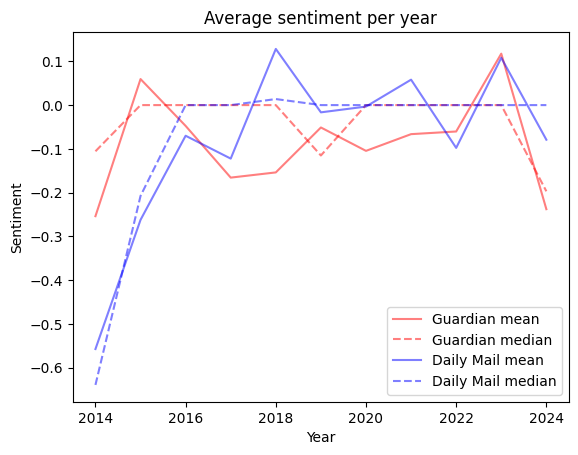

In [53]:
# plot average sentiment per year against published for each paper
df_dm = df.copy()[df['paper'] == 'dailymail']
df_g = df.copy()[df['paper'] == 'guardian']

# group by year of published
df_dm['published'] = df_dm['published'].apply(lambda x: datetime.fromtimestamp(x).year)
df_g['published'] = df_g['published'].apply(lambda x: datetime.fromtimestamp(x).year)

# group by published
df_dm.head(5)
df_dm = df_dm[["published", "headline_sentiment"]]
df_g = df_g[["published", "headline_sentiment"]]


# group by year and store mean and median
df_dm = df_dm.groupby('published').agg(['mean', 'median'])
df_g = df_g.groupby('published').agg(['mean', 'median'])

# remove pre 2016 entries
df_dm = df_dm[df_dm.index >= 2014]
df_g = df_g[df_g.index >= 2014]

# plot
plt.plot(df_g['headline_sentiment']['mean'], label='Guardian mean', color="red", alpha = 0.5)
plt.plot(df_g['headline_sentiment']['median'], label='Guardian median', linestyle='--', color="red", alpha = 0.5)
plt.plot(df_dm['headline_sentiment']['mean'], label='Daily Mail mean', color="blue", alpha = 0.5)
plt.plot(df_dm['headline_sentiment']['median'], label='Daily Mail median', linestyle= "--", color="blue", alpha = 0.5)

# get correlation coefficients and p-values for each variable
print("Correlation coefficients and p values (< 0.05)")
for att in ['mean', 'median']:
  for d in [df_g, df_dm]:
    c, p = stats.pearsonr(d['headline_sentiment'][att], d.index)
    print(att + ": " + str(c) + " " + str(p) + "  " + str(p < 0.05))

plt.ylabel('Sentiment')
plt.xlabel('Year')
plt.title('Average sentiment per year')

plt.legend()
plt.show()

Figure 12

<ipython-input-54-f26271ac1980>:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_dm = df_dm.groupby(['published', 'quartile']).size().reset_index(name='count')
<ipython-input-54-f26271ac1980>:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_g = df_g.groupby(['published', 'quartile']).size().reset_index(name='count')


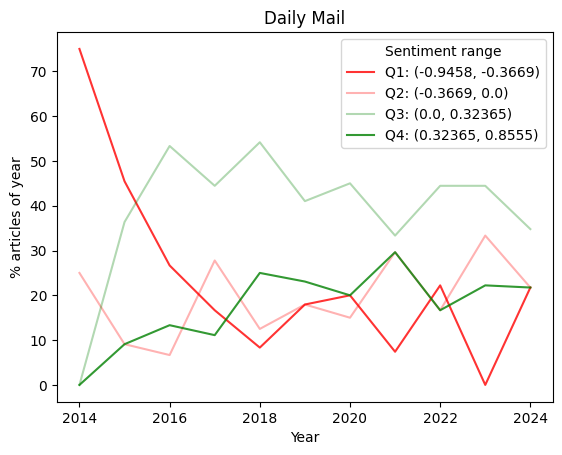

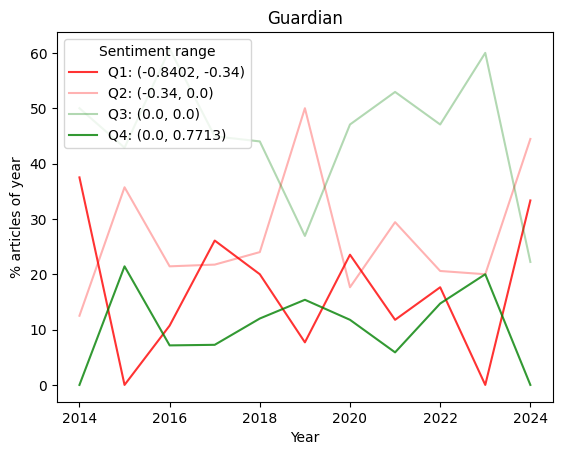

Percentage headlines
Absolute headlines


In [54]:
# get min, 25% etc for each paper

df2 = df.copy()
#ignore 2014 articles
#df2 = df2[df2['published'] > 1420070399]

quartiles_df = df2.groupby('paper').describe()

# add quartile column which equals either 1,2,3 or 4
df_dm = df2.copy()[df2['paper'] == 'dailymail']
df_g = df2.copy()[df2['paper'] == 'guardian']
#quartile cut for each
dm_des = df_dm['headline_sentiment'].describe()
g_des = df_g['headline_sentiment'].describe()

df_dm['quartile'] = pd.cut(df_dm['headline_sentiment'], 4, labels=[1, 2, 3, 4])
df_g['quartile'] = pd.cut(df_g['headline_sentiment'], 4, labels=[1, 2, 3, 4])

# convert published timestamp to datetime
df_dm['published'] = df_dm['published'].apply(lambda x: datetime.fromtimestamp(x).year)
df_g['published'] = df_g['published'].apply(lambda x: datetime.fromtimestamp(x).year)

# for each quartile plot count against published
# group by year and quartile
df_dm = df_dm.groupby(['published', 'quartile']).size().reset_index(name='count')
df_g = df_g.groupby(['published', 'quartile']).size().reset_index(name='count')

# add sum column
df_dm['sum'] = df_dm.groupby('published')['count'].transform('sum')
df_g['sum'] = df_g.groupby('published')['count'].transform('sum')

# add count_pct column
df_dm['count_pct'] = df_dm['count'] / df_dm['sum'] * 100
df_g['count_pct'] = df_g['count'] / df_g['sum'] * 100

dm_des = [dm_des['min'], dm_des['25%'], dm_des['50%'], dm_des['75%'], dm_des['max']]
g_des = [g_des['min'], g_des['25%'], g_des['50%'], g_des['75%'], g_des['max']]

#plot df_dm as scatter between published and quartile count
for q in [1, 2, 3, 4]:
  a = 0.8 if q in [1,4] else 0.3
  c = 'red' if q in [1,2] else 'green'

  df_slice = df_dm[df_dm['quartile'] == q]
  label = f'Q{q}: ({dm_des[q-1]}, {dm_des[q]})'
  plt.plot(df_slice['published'], df_slice['count_pct'], label=label, alpha = a, color = c)
plt.legend(title = "Sentiment range")
plt.title('Daily Mail')
plt.xlabel('Year')
plt.ylabel('% articles of year')
plt.show()

for q in [1, 2, 3, 4]:
  a = 0.8 if q in [1,4] else 0.3
  c = 'red' if q in [1,2] else 'green'

  df_slice = df_g[df_g['quartile'] == q]
  label = f'Q{q}: ({g_des[q-1]}, {g_des[q]})'
  plt.plot(df_slice['published'], df_slice['count_pct'], label=label, alpha = a, color = c)

plt.legend(title = "Sentiment range")
plt.title('Guardian')
plt.xlabel('Year')
plt.ylabel('% articles of year')
plt.show()

# for each q see if there's a correlation between count_pct and published

# make a data frame for quartile, corr, p
for att in ['count_pct', 'count']:
  if att == 'count_pct': print("Percentage headlines")
  else: print("Absolute headlines")
  df_corr_pct = pd.DataFrame(columns=['quartile', 'paper', 'corr', 'p'])
  df_corr_pct.set_index(['quartile', 'paper'], inplace=True)

  for q in [1,2,3,4]:
    df_slice = df_dm[df_dm['quartile'] == q]
    c, p = stats.pearsonr(df_slice['published'], df_slice[att])
    df_corr_pct.at[(q, 'dailymail'), 'corr'] = c
    df_corr_pct.at[(q, 'dailymail'), 'p'] = p

  # do the same for guardian
  for q in [1,2,3,4]:
    df_slice = df_g[df_g['quartile'] == q]
    c, p = stats.pearsonr(df_slice['published'], df_slice[att])
    df_corr_pct.at[(q, 'guardian'), 'corr'] = c
    df_corr_pct.at[(q, 'guardian'), 'p'] = p

  # sort by p value ascending
  df_corr_pct.sort_values(by=['p'], ascending=True, inplace=True)

  # No relationship between sentiment and time








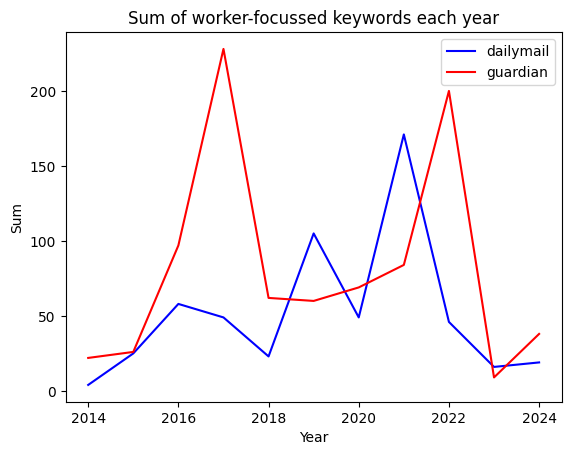

In [55]:
# next try topic modelling
# filter by newspaper
# maybe compute a value which takes into account importance AND sentiment
# make a scatter plot for each paper that plots importance of word (from topic modelling) with sentiment
# i think concat(str) THEN TOPIC MODELLING risks prioritising lowest common denominator words
# e.g. suppose strike is in 50% but DRIVER, UBER are in 100%, then it's gonna be kind of dead
# therefore, collapse after doing the analysis

import re
def match_word(text, pattern):
  pattern = rf'\b{pattern}\b'
  matches = re.findall(pattern, text)
  return len(matches)


# matches bodies and headlines
def match_words(df, patterns_dict, ignore = ["customer"]):
  for pattern in patterns_dict:
    # ignore if word included in columns
    if pattern in df.columns:
      continue
    # Count occurrences of word in bodies preceded and followed by punctuation or space
    # make a pattern of word followed and preceded by punctuation
    df[pattern] = df['bodies'].apply(lambda x : match_word(x, patterns_dict[pattern]))
  df['sum'] = 0
  for pattern in patterns_dict:
    if pattern not in ignore:
      df['sum'] += df[pattern]

  return df

keyword_regexes = {
    'worker' : r'workers?',
    'protest': r'protest(er|ers|ing|ed)?',
    'strike': r'strik(er|es|ers|ing|e)',
    'union' : r'union(ise|s|isation|ising|ised|ize|ization|ized|izing)?',
    'regulate' : r'regulat(ion|e|ing|or|ions|es|ed|ors)',
    'exploitative' : r'exploit(ative|ing|ed)?',
    'customer' : r'customer(s)?'
}

def create_df_matched(df, keyword_regexes, m_res, ignore=['customer']):
    # do guardian and daily mail separately
    dfg = collapse_df(df[df['paper'] == 'guardian'], m_res, y_res=1)
    dfm = collapse_df(df[df['paper'] == 'dailymail'], m_res, y_res=1)

    dfg = match_words(dfg, keyword_regexes, ignore=ignore)
    dfm = match_words(dfm, keyword_regexes, ignore=ignore)

    # concat
    dfg['paper'] = 'guardian'
    dfm['paper'] = 'dailymail'
    df_matched = pd.concat([dfg, dfm])
    df_matched = df_matched.sort_values(by=['published'])
    return df_matched

df_matched = create_df_matched(df, keyword_regexes, 1)
# convert index to just year
df_matched['year'] = df_matched.index
df_matched['year'] = df_matched['year'].apply(lambda x: x[0:4]).apply(int)

# Create a figure and axes


# Group the dataframe by 'paper' and plot 'sum' against 'published'
for paper, group in df_matched.groupby('paper'):
    if paper == 'dailymail': c = 'blue'
    else: c = 'red'
    plt.plot(group.year, group['sum'], label=paper, color = c)

# Let's also plot daily mail adjusted to guardians total number of words


# Set plot title and labels

plt.title('Sum of worker-focussed keywords each year')
plt.xlabel('Year')
plt.ylabel('Sum')

# Add a legend
plt.legend()

# Display the plot
plt.show()



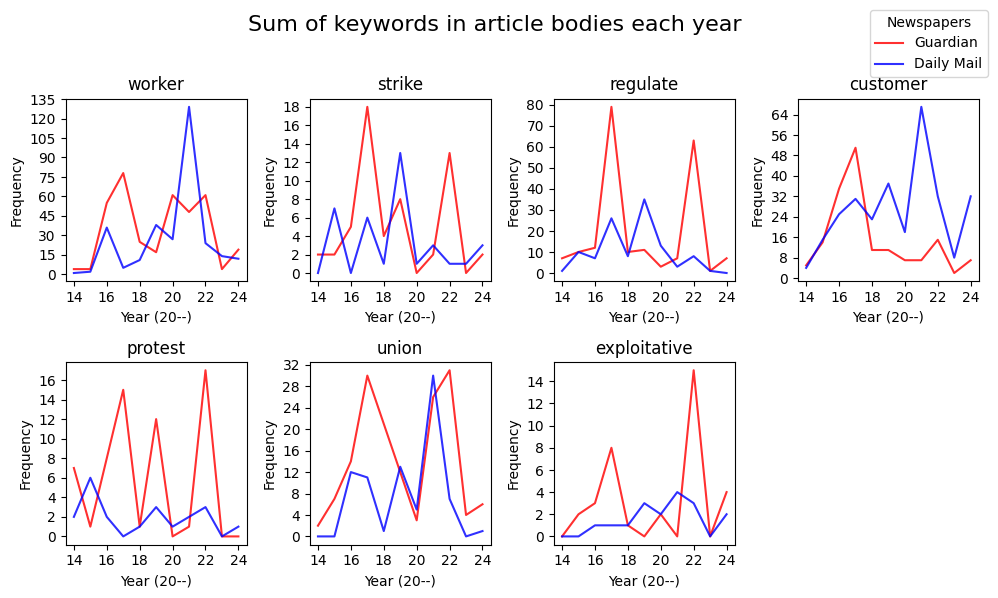

In [56]:
from matplotlib.ticker import MaxNLocator
# We're gonna plot YEAR published against frequency of keywords in headlines and then in bodies
keyword_regexes = {
    'worker' : r'workers?',
    'protest': r'protest(er|ers|ing|ed)?',
    'strike': r'strik(er|es|ers|ing|e)',
    'union' : r'union(ise|s|isation|ising|ised|ize|ization|ized|izing)?',
    'regulate' : r'regulat(ion|e|ing|or|ions|es|ed|ors)',
    'exploitative' : r'exploit(ative|ing|ed)?',
    'customer' : r'customer(s)?'
}

df = load_articles('./final_data.json')

# just keep published headline body and paper
df = df[['published', 'headline', 'body', 'paper']]

# convert published to year published
df['published'] = df['published'].apply(lambda x: datetime.fromtimestamp(x).year)

# concatenate headline and body columns, adding a new column type which records which type it is
df2 = df.copy()

df['text'] = df['headline']
df['type'] = 'headline'
df2['text'] = df2['body']
df2['type'] = 'body'
# drop headline and body from both
df.drop(columns=['headline', 'body'], inplace=True)
df2.drop(columns=['headline', 'body'], inplace=True)
df = pd.concat([df, df2])
# order df by published
df.sort_values(by=['published'], inplace=True)

# match keywords for every text adding a new column for each
for k in keyword_regexes:
  df[k] = df['text'].apply(lambda x : match_word(x, keyword_regexes[k]))

# add sum column
df['sum'] = 0
for k in keyword_regexes:
  # ignore customer
  if k not in ['customer']: df['sum'] += df[k]

# group by published
df = df.groupby(['published', 'paper', 'type']).sum()

#ungroup
df.reset_index(inplace=True)

# display these plots in a 2x4 grid

fig, axes = plt.subplots(2, 4, figsize=(10, 6))

# for each type
counter = 0
for k in keyword_regexes:
  df_type = df[df['type'] == 'body']
  # for each paper
  # plot frequency of sum for each paper on graph
  for paper in ['guardian', 'dailymail']:
    df_paper = df_type[df_type['paper'] == paper]
    if paper == 'dailymail': c = 'blue'
    else: c = 'red'
    # group by published
    # plot sum against published
    ax = axes[counter % 2, counter // 2]
    ax.plot(df_paper['published'] - 2000, df_paper[k], label=paper, color = c, alpha = 0.81)
    ax.set_title(k)
    ax.set_xlabel('Year (20--)')
    ax.set_ylabel('Frequency')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # For x-axis
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))  # For y-axis
  counter += 1

fig.suptitle("Sum of keywords in article bodies each year\n", fontsize=16)
fig.legend(title="Newspapers", labels=['Guardian', 'Daily Mail'], loc='upper right', bbox_to_anchor=(1, 1))
fig.delaxes(axes[1, 3])
plt.tight_layout()
plt.show()

# drop year


In [57]:
df.sample(5)

df_welch = pd.DataFrame(columns=['keyword', 'test statistic', 'p-value'])
df_welch.set_index('keyword', inplace=True)
for k in keyword_regexes:
  if k == 'customer': alternative = 'less'
  else: alternative = 'greater'
  t, p = stats.ttest_ind(df[df['paper'] == 'guardian'][k], df[df['paper'] == 'dailymail'][k], equal_var= False, alternative=alternative)
  df_welch.at[k, 'test statistic'] = t
  df_welch.at[k, 'p-value'] = p


df_welch['p-value < 0.05'] = df_welch['p-value'].apply(lambda x: x < 0.05)
df_welch.head(10)


,test statistic,p-value,p-value < 0.05
keyword,,,
worker,0.393271,0.348066,False
protest,1.459484,0.078612,False
strike,0.876594,0.19317,False
union,1.399713,0.084876,False
regulate,0.903141,0.186942,False
exploitative,1.021547,0.158224,False
customer,-1.323224,0.096813,False


In [58]:
# this is going to do topic modelling for each sentence that includes keywords
# first step is to combine all bodies into a single block of text
df = load_articles('./final_data.json')
df.head(5)

# merge all bodies of each paper into list of sentences
body_dm = sent_tokenize(". ".join(df[df['paper'] == 'dailymail']['body']))
body_g = sent_tokenize(". ".join(df[df['paper'] == 'guardian']['body']))

all_sents = body_dm + body_g

# two lists of sentences
# keep only sentences that include the keywords
"""body_dm = [s for s in body_dm if any(match_word(s, keyword) for keyword in keyword_regexes.values())]
body_g = [s for s in body_g if any(match_word(s, keyword) for keyword in keyword_regexes.values())]"""

#for s in body_dm: print(s)

# let's make a dataframe
# PAPER | SENTENCE | keywords (t/f) | SENTIMENT | 5 TOPICS
df_sent = pd.DataFrame(columns=['paper', 'sentence'])
df_sent['paper'] = ['dailymail'] * len(body_dm) + ['guardian'] * len(body_g)
df_sent['sentence'] = body_dm + body_g


for k in keyword_regexes:
    df_sent[k] = df_sent['sentence'].apply(lambda x : match_word(x, keyword_regexes[k]) > 0)

df_sent['sentiment'] = df_sent['sentence'].apply(get_sentiment)
# topic model
#df_sent['topics'] = df_sent['sentence'].apply(get_topics_text)



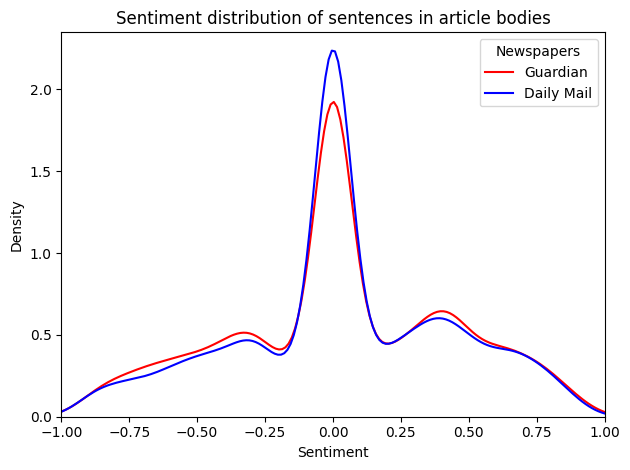

In [59]:

# also do overall
sns.kdeplot(data=df_sent, x="sentiment", hue='paper', fill=False, common_norm=False, palette={'guardian': 'red', 'dailymail': 'blue'})
# set colors to blue and red
plt.title("Sentiment distribution of sentences in article bodies")
plt.xlim(-1, 1)
plt.legend(['Guardian', 'Daily Mail']).set_title("Newspapers")
plt.xlabel('Sentiment')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


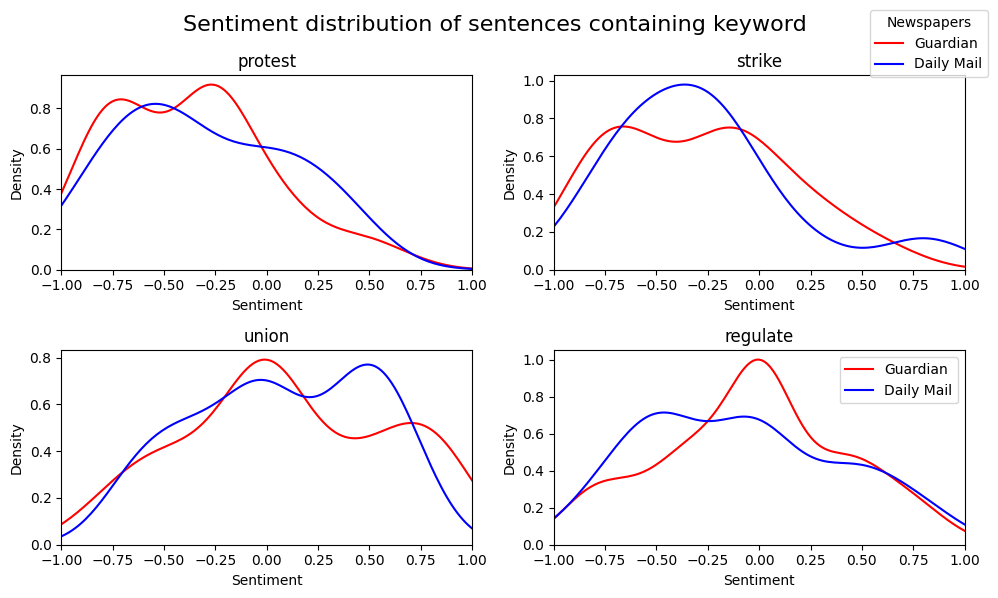

Daily mail: 8162 guardian: 7993


In [60]:

# create plot
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
# create sentiment kde
counter = 0
for k in ['protest', 'strike', 'union', 'regulate']:
  if df_sent[k].any():
    ax = axes[counter // 2, counter % 2]
    sns.kdeplot(data=df_sent[df_sent[k] == True], x="sentiment", hue='paper', fill=False, common_norm=False, ax=ax, palette={'guardian': 'red', 'dailymail': 'blue'})
    #sns.kdeplot(data=df_sent, x="sentiment", hue='paper', fill=True, common_norm=False, alpha = 0.1)
    ax.set_title(k)
    ax.set_xlim(-1, 1)
    # make graphs small size
    ax.set_xlabel('Sentiment')
    ax.set_ylabel('Density')
    #hide legend
    ax.get_legend().remove()
    counter += 1

fig.suptitle("Sentiment distribution of sentences containing keyword", fontsize=16)
fig.legend(title="Newspapers", labels=['Guardian', 'Daily Mail'], loc='upper right', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.legend(['Guardian', 'Daily Mail'])
plt.show()

# add keywords as labels
#plt.legend(labels=keyword_regexes.keys())
# print how many sentences are daily mail and how many are guardian
print("Daily mail: " + str(len(body_dm)) + " guardian: " + str(len(body_g)))

# conclude here that sentiment analysis doesn't tell us much
# e.g., we expect both papers to portray strikes badly
# the difference is that guardian might focus more on worker-oriented stuff whereas
# daily mail will look more at delays (consumer-facing issues)

#df_sent.sample(10)

In [61]:
# do Welch tests to see difference in sentiment between papers for all keywords
df_welch = pd.DataFrame(columns=['keyword', 'test statistic', 'p-value'])
df_welch.set_index('keyword', inplace=True)

df_sent.sample(5)

for k in keyword_regexes:
  df_slice = df_sent[df_sent[k] == True]
  t, p = stats.ttest_ind(df_slice[df_slice['paper'] == 'guardian']['sentiment'], df_slice[df_slice['paper'] == 'dailymail']['sentiment'], equal_var= False, alternative="two-sided")
  df_welch.at[k, 'test statistic'] = t
  df_welch.at[k, 'p-value'] = p


df_welch

,test statistic,p-value
keyword,,
worker,-0.763101,0.445731
protest,-0.682753,0.499508
strike,-0.185992,0.852992
union,0.398963,0.690403
regulate,0.952959,0.341763
exploitative,-1.440614,0.157707
customer,-0.676968,0.498944


In [62]:
df = load_articles('./final_data.json')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token.isalnum() and token not in stop_words]
    return ' '.join(tokens)

for paper in ['guardian', 'dailymail']:
  print(paper)
  print("-" * 20)
  articles = df[df['paper'] == paper]['body']

  # process the articles
  articles = articles.apply(preprocess_text)

  # as list
  articles = articles.tolist()

  # convert to sentences
  all_sentences = []
  for article in articles:
    sentences = sent_tokenize(article)
    all_sentences.extend(sentences)

  vectorizer = TfidfVectorizer(max_df=0.85, min_df=2, max_features=1000)
  tfidf_matrix = vectorizer.fit_transform(all_sentences)

  lda = LatentDirichletAllocation(n_components=100, random_state=42) # n_components is the number of topics to discover
  lda_model = lda.fit(tfidf_matrix)

  topic_distributions = lda_model.transform(tfidf_matrix)

  # let's look at sentences with keywords
  keywords = list(keyword_regexes.keys())
  for k in keywords:
    filtered_sentences = [sentence for sentence in all_sentences if match_word(sentence, keyword_regexes[k])]
    filtered_sentence_indices = [all_sentences.index(sentence) for sentence in filtered_sentences]
    filtered_topic_distributions = topic_distributions[filtered_sentence_indices]

    # Analyze topics for filtered sentences:
    topics = {}
    """for sentence_index, topic_distribution in zip(filtered_sentence_indices, filtered_topic_distributions):
        print(f"Sentence ({k}): '{all_sentences[sentence_index]}'")
        dominant_topic = topic_distribution.argmax()

        print(f"Dominant topic: {dominant_topic}")

        # To get the top keywords for the dominant topic:
        feature_names = vectorizer.get_feature_names_out()
        print("Top keywords for the dominant topic:")
        top_keywords = " ".join([feature_names[i] for i in lda.components_[dominant_topic].argsort()[:-10 - 1:-1]])

        print(top_keywords + " : " + str(get_sentiment(top_keywords)))
        print("-" * 20)  # Separator"""



guardian
--------------------
dailymail
--------------------


In [63]:
# let's try tf-idf scores

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

stemmer = PorterStemmer()
def stem(token):
  if any(match_word(token, k) for k in keyword_regexes):
    return token
  return stemmer.stem(token)

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token.isalnum() and token not in stop_words]
    tokens = [stem(token) for token in tokens if token.isalnum() and token not in stop_words]
    return ' '.join(tokens)

df = load_articles('./final_data.json')
df['body'] = df['body'].apply(preprocess_text)
dfs = {
    'guardian': {},
    'dailymail': {}
}

for paper in ['guardian', 'dailymail']:
  for k in keyword_regexes:
    dfs[paper][k] = None

for paper in ['guardian', 'dailymail']:
  all_sentences = list(df[df['paper'] == paper]['body'])
  vectorizer = TfidfVectorizer(stop_words='english', max_df=.4, min_df=.075)
  vectorizer.fit(all_sentences)

  # Transform the protest sentences into a TF-IDF matrix
  tfidf_matrix = vectorizer.transform(all_sentences)
  # Get the feature names (terms)
  feature_names = vectorizer.get_feature_names_out()

  # Get the average TF-IDF score for each word in the protest sentences
  avg_tfidf_all = tfidf_matrix.mean(axis=0).A1

  # Create a DataFrame to store words and their average TF-IDF scores
  df_tfidf_all = pd.DataFrame({'word': feature_names, 'avg_tfidf': avg_tfidf_all})

  # set word index
  df_tfidf_all.set_index('word', inplace=True)

  print(paper)
  print("-" * 20)
  for k in keyword_regexes:
    subset_sentences = [sentence for sentence in all_sentences if match_word(sentence, keyword_regexes[k])]

    # Transform the protest sentences into a TF-IDF matrix
    tfidf_matrix = vectorizer.transform(subset_sentences)

    # Get the feature names (terms)
    feature_names = vectorizer.get_feature_names_out()

    # Get the average TF-IDF score for each word in the protest sentences
    avg_tfidf_protest = tfidf_matrix.mean(axis=0).A1

    # Create a DataFrame to store words and their average TF-IDF scores
    df_tfidf_protest = pd.DataFrame({'word': feature_names, 'avg_tfidf': avg_tfidf_protest})

    # add avgtfidf values from all_sentences df
    df_tfidf_protest['avg_tfidf_all'] = df_tfidf_protest['word'].apply(lambda x: df_tfidf_all.at[x, 'avg_tfidf'])


    df_tfidf_protest['diff'] = df_tfidf_protest['avg_tfidf'] - df_tfidf_protest['avg_tfidf_all']
    # Sort the DataFrame by average TF-IDF score in descending order
    df_tfidf_protest = df_tfidf_protest.sort_values(by=['diff'], ascending=False)

    # remove rows if their word matches the regex
    #df_tfidf_protest = df_tfidf_protest[df_tfidf_protest['word'].apply(lambda x: match_word(k, x))]

    # remove words with neutral sentiment
    df_tfidf_protest = df_tfidf_protest[df_tfidf_protest['word'].apply(lambda x: abs(get_sentiment(x)) > 0.2)]


    # Get the top 10 words with the highest TF-IDF scores (excluding "protest")
    top_10_words = df_tfidf_protest.head(10)['word'].tolist()
    dfs[paper][k] = top_10_words

    print(f"Top 10 words associated with sentences containing {k}:")
    print(top_10_words)


# corpus will be all articles (maybe seperate for newspapers)
# and then the document will be combined sentences with keyword for each keyword

guardian
--------------------
Top 10 words associated with sentences containing worker:
['holiday', 'accept', 'benefit', 'sick', 'protest', 'treat', 'protect', 'free', 'low', 'cut']
Top 10 words associated with sentences containing protest:
['protest', 'cut', 'leak', 'ban', 'benefit', 'scandal', 'treat', 'great', 'good', 'resign']
Top 10 words associated with sentences containing strike:
['protest', 'cut', 'benefit', 'friend', 'attack', 'difficult', 'harass', 'ban', 'support', 'poor']
Top 10 words associated with sentences containing union:
['holiday', 'accept', 'protest', 'protect', 'cut', 'benefit', 'fair', 'support', 'freedom', 'grant']
Top 10 words associated with sentences containing regulate:
['fail', 'risk', 'protect', 'allow', 'care', 'sure', 'freedom', 'commit', 'grant', 'fit']
Top 10 words associated with sentences containing exploitative:
['leak', 'fair', 'care', 'hand', 'freedom', 'attack', 'great', 'sick', 'free', 'protect']
Top 10 words associated with sentences containin

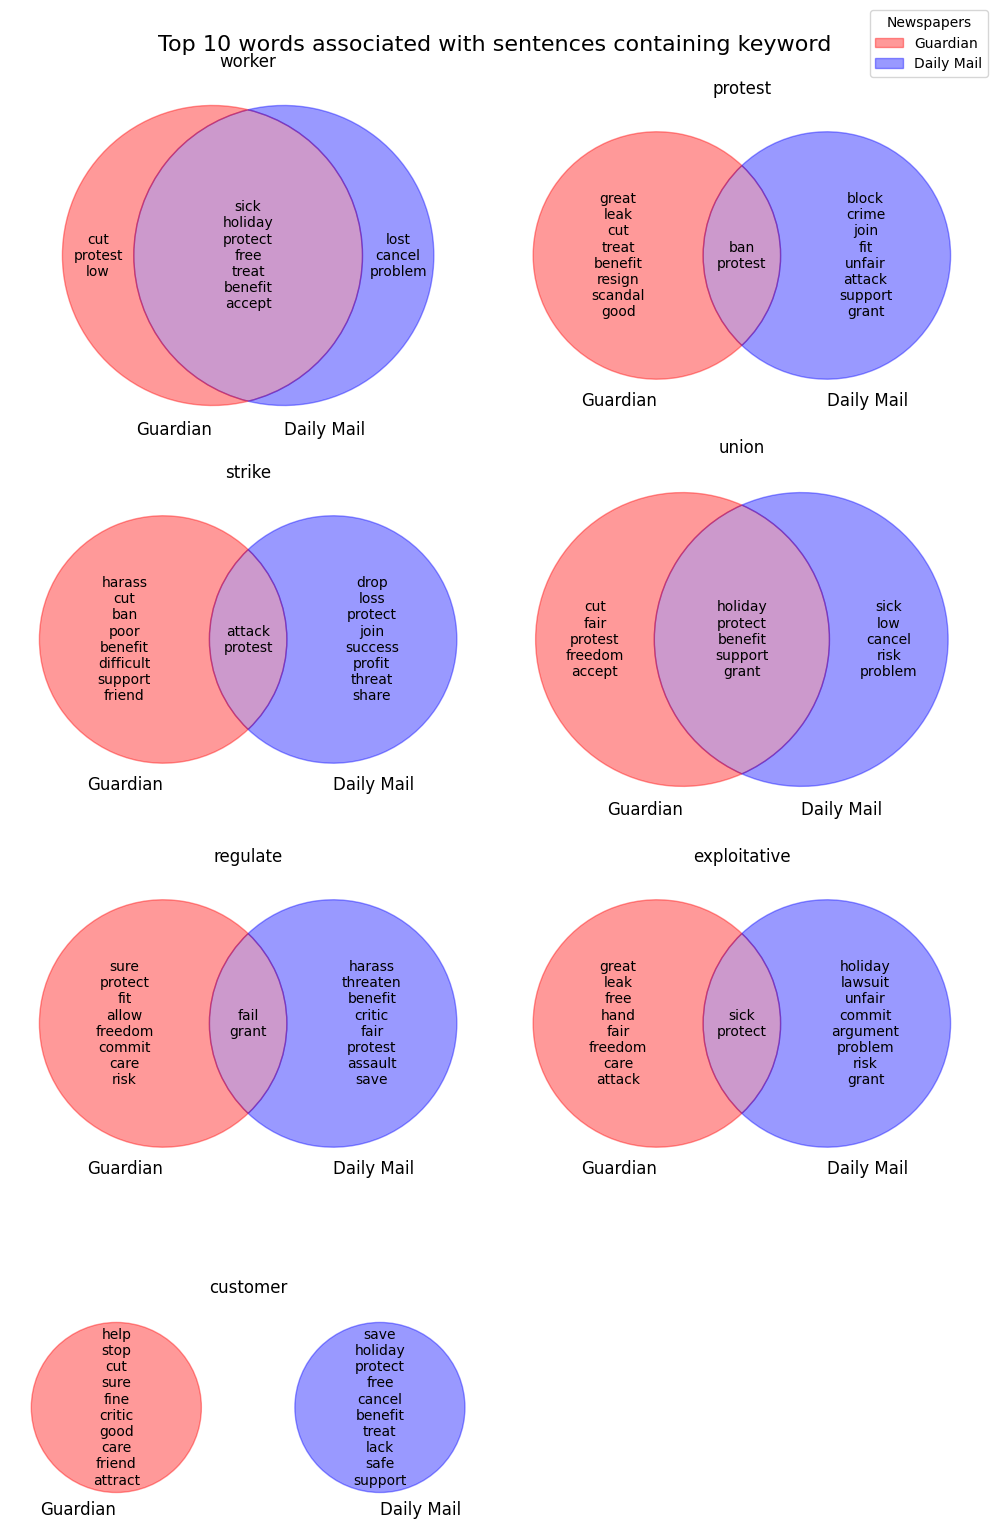

In [64]:

# make venn diagrams
# loop keywords
# 2 by 4 subplot
fig, axes = plt.subplots(4, 2, figsize=(10, 16))  # 2 rows, 4 columns
counter = -1

for k in keyword_regexes:
  counter += 1
  ax = axes[counter // 2, counter % 2]

  list1 = dfs['guardian'][k]
  list2 = dfs['dailymail'][k]
  # make a venn diagram comparing these lists
  v = venn2(subsets = (set(dfs['guardian'][k]), set(dfs['dailymail'][k])), set_labels = ('Guardian', 'Daily Mail'), ax = ax)

  # set venn colours
  v.get_patch_by_id('10').set_color('red')
  v.get_patch_by_id('01').set_color('blue')
  if v.get_patch_by_id('11') != None: v.get_patch_by_id('11').set_color('purple')

  # Get the set labels
  label1 = v.get_label_by_id('10')  # Words only in list1
  label2 = v.get_label_by_id('01')  # Words only in list2
  label_intersect = v.get_label_by_id('11')  # Words in both lists

  # Update the labels with word lists
  label1.set_text('\n'.join(list(set(list1) - set(list2))))
  label2.set_text('\n'.join(list(set(list2) - set(list1))))
  if label_intersect != None: label_intersect.set_text('\n'.join(list(set(list1) & set(list2))))


  # show the words inside the diagram
  ax.set_title(k)

fig.delaxes(axes[3, 1])
fig.suptitle("Top 10 words associated with sentences containing keyword", fontsize=16)
fig.legend(title="Newspapers", labels=['Guardian', 'Daily Mail'], loc='upper right', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()